In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

iris = load_iris()
X = iris.data
print("Dataset shape:", X.shape)

Dataset shape: (150, 4)


In [4]:
kmeans_scores = []
k_range = range(2, 11)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    kmeans_scores.append(score)

agg_scores = []

for k in k_range:
    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    agg_scores.append(score)

eps_values = np.arange(0.3, 1.6, 0.1)
dbscan_scores = []

for eps in eps_values:
    model = DBSCAN(eps=eps, min_samples=5)
    labels = model.fit_predict(X)

    unique = set(labels)
    if -1 in unique:
        unique.remove(-1)

    if len(unique) < 2:
        dbscan_scores.append(np.nan)
    else:
        mask = labels != -1
        dbscan_scores.append(silhouette_score(X[mask], labels[mask]))

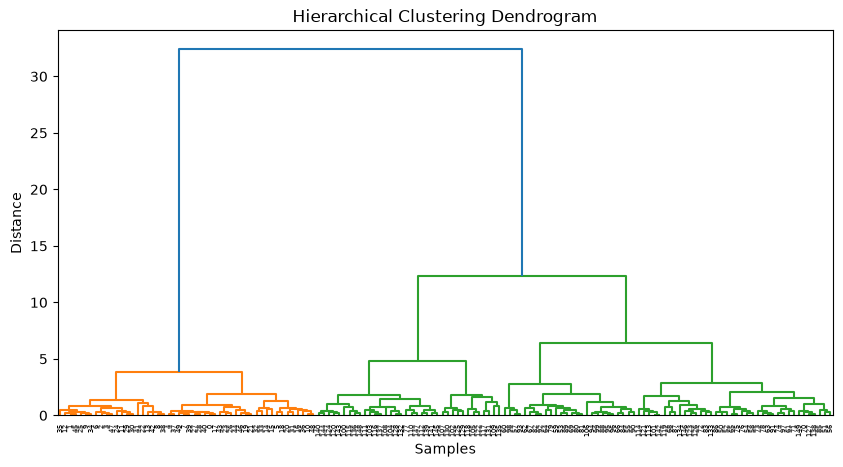

In [5]:
plt.figure(figsize=(10,5))
Z = linkage(X, method="ward")
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

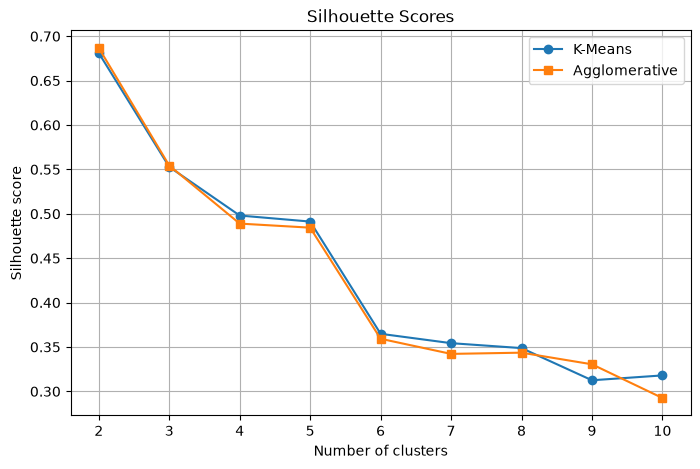

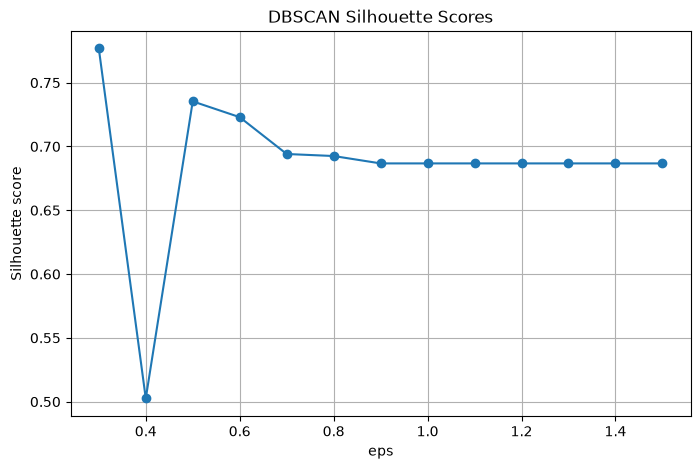

Best K-Means clusters: 2
Best K-Means score: 0.681
Best Agglomerative clusters: 2
Best Agglomerative score: 0.687
Best DBSCAN eps: 0.3
Best DBSCAN score: 0.777


In [6]:
plt.figure(figsize=(8,5))
plt.plot(list(k_range), kmeans_scores, marker="o", label="K-Means")
plt.plot(list(k_range), agg_scores, marker="s", label="Agglomerative")

plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("Silhouette Scores")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(eps_values, dbscan_scores, marker="o")
plt.xlabel("eps")
plt.ylabel("Silhouette score")
plt.title("DBSCAN Silhouette Scores")
plt.grid(True)
plt.show()

best_kmeans = list(k_range)[np.argmax(kmeans_scores)]
best_agg = list(k_range)[np.argmax(agg_scores)]

print("Best K-Means clusters:", best_kmeans)
print("Best K-Means score:", round(max(kmeans_scores),3))

print("Best Agglomerative clusters:", best_agg)
print("Best Agglomerative score:", round(max(agg_scores),3))

valid = [x for x in dbscan_scores if not np.isnan(x)]
if valid:
    idx = np.nanargmax(dbscan_scores)
    print("Best DBSCAN eps:", round(eps_values[idx],2))
    print("Best DBSCAN score:", round(dbscan_scores[idx],3))
